In [149]:
# legacy_linking_v2 — CELL L1: Setup and load raw Excel inputs for legacy_wrangling_v2

import pandas as pd
from pathlib import Path

BASE    = Path("/Users/davekokel/Projects/carp_v2")
RAW     = BASE / "seed_kits" / "legacy_wrangling_v2" / "raw"
WORKING = BASE / "seed_kits" / "legacy_wrangling_v2" / "working"

roi_paths_path     = RAW / "2025-11-13-092338-korra_aang_roi_root_tiffs_good-3.xlsx"
imaging_sheet_path = RAW / "2025-11-13-124226-imaging_sheet.xlsx"

df_roi_paths = pd.read_excel(roi_paths_path)
df_imaging   = pd.read_excel(imaging_sheet_path)
df_roi_paths.shape, df_imaging.shape



((976, 7), (306, 20))

In [150]:
# CELL L2 — standardize ROI paths

df_roi_paths["roi_dir"]  = df_roi_paths["roi_dir"].astype(str).str.strip()
df_roi_paths["roi_name"] = df_roi_paths["roi_name"].astype(str).str.strip()
ROI_KEY = "roi_dir"

In [151]:
# CELL L2a — drop ROI rows that do not contain a parsable experiment folder (e.g. analysis_test)

import re

def has_experiment_folder(path: str) -> bool:
    """
    True if the path contains a segment like 'YYYYMMDD_<something>'.
    """
    if path is None:
        return False
    parts = str(path).split("/")
    return any(re.match(r"\d{8}_.+", p) for p in parts)

mask_valid = df_roi_paths["roi_dir"].apply(has_experiment_folder)

n_total = len(df_roi_paths)
n_keep = mask_valid.sum()
n_drop = n_total - n_keep

print(f"L2a: df_roi_paths rows total: {n_total}")
print(f"L2a: keeping {n_keep} rows with valid experiment_folder, dropping {n_drop} rows without.")

if n_drop > 0:
    print("\nL2a: Sample of dropped rows (non-experiment / analysis paths):")
    print(df_roi_paths.loc[~mask_valid, ["roi_dir"]].head(20))

df_roi_paths = df_roi_paths.loc[mask_valid].reset_index(drop=True)

L2a: df_roi_paths rows total: 976
L2a: keeping 975 rows with valid experiment_folder, dropping 1 rows without.

L2a: Sample of dropped rows (non-experiment / analysis paths):
                                               roi_dir
419  /clusterfs/vast/abcabc/Korra_Foundation/analys...


In [152]:
# CELL L2b — derive roi_fish_name and roi_anatomical_location from fish / roi_name

import re

# roi_fish_name: just a normalized copy of the fish column
df_roi_paths["roi_fish_name"] = df_roi_paths["fish"].astype(str).str.strip()

def extract_anatomical_from_roi_name(name: str) -> str:
    """
    Expected patterns:
      roi1_tail              -> tail
      roi2_hindbrain_spine   -> hindbrain_spine
      roi1                    -> "" (no anatomical suffix)
      roi1_test              -> test
      roi2_2                 -> 2
    Anything that doesn't match 'roi<digits>[_suffix]' returns "".
    """
    if name is None:
        return ""
    s = str(name).strip()
    m = re.match(r"^(roi\d+)(?:_(.+))?$", s)
    if not m:
        return ""
    suffix = m.group(2)
    return "" if suffix is None else suffix

df_roi_paths["roi_anatomical_location"] = df_roi_paths["roi_name"].apply(extract_anatomical_from_roi_name)

print("Derived columns added in df_roi_paths:")
print("  roi_fish_name")
print("  roi_anatomical_location")
print("\nSample:")
print(df_roi_paths[["roi_dir", "fish", "roi_name", "roi_fish_name", "roi_anatomical_location"]].head(20))

Derived columns added in df_roi_paths:
  roi_fish_name
  roi_anatomical_location

Sample:
                                              roi_dir                  fish  \
0   /clusterfs/vast/abcabc/Korra_Foundation/202504...           fish1_72hpf   
1   /clusterfs/vast/abcabc/Korra_Foundation/202504...           fish1_72hpf   
2   /clusterfs/vast/abcabc/Korra_Foundation/202504...           fish1_24hpf   
3   /clusterfs/vast/abcabc/Korra_Foundation/202504...           fish1_24hpf   
4   /clusterfs/vast/abcabc/Korra_Foundation/202504...           fish2_48hpf   
5   /clusterfs/vast/abcabc/Korra_Foundation/202504...  fish3_mem-halo_24hpf   
6   /clusterfs/vast/abcabc/Korra_Foundation/202504...  fish3_mem-halo_24hpf   
7   /clusterfs/vast/abcabc/Korra_Foundation/202504...  fish4_mem-halo_48hpf   
8   /clusterfs/vast/abcabc/Korra_Foundation/202504...  fish4_mem-halo_48hpf   
9   /clusterfs/vast/abcabc/Korra_Foundation/202504...  fish4_mem-halo_48hpf   
10  /clusterfs/vast/abcabc/Korra_Foundati

In [153]:
# CELL L2c — extract experiment_folder, fish_folder, roi_folder, and imaging_date_from_path

import re

def extract_experiment_folder(path):
    """
    Extract the experiment folder from roi_dir:
      .../20250428_mem_histone/fish1_72hpf/roi1_tail -> 20250428_mem_histone
    """
    parts = str(path).split("/")
    for p in parts:
        if re.match(r"\d{8}_.+", p):
            return p
    return None

def extract_imaging_date_from_exp_folder(exp_folder):
    """
    From experiment_folder like '20250428_mem_histone' -> '20250428'
    """
    if exp_folder is None:
        return None
    m = re.match(r"^(\d{8})_", str(exp_folder))
    return m.group(1) if m else None

def extract_fish_folder(path):
    """
    FISH folder is immediate child of experiment_folder:
      .../20250428_mem_histone/fish1_72hpf/roi1_tail -> fish1_72hpf
    """
    parts = str(path).split("/")
    for i, p in enumerate(parts):
        if re.match(r"\d{8}_.+", p) and i + 1 < len(parts):
            return parts[i + 1]
    return None

def extract_roi_folder(path):
    """
    ROI folder is the last component:
      .../fish1_24hpf/roi1_tail -> roi1_tail
    """
    return str(path).rstrip("/").split("/")[-1]

df_roi_paths["experiment_folder"]         = df_roi_paths["roi_dir"].apply(extract_experiment_folder)
df_roi_paths["imaging_date_from_path"]    = df_roi_paths["experiment_folder"].apply(extract_imaging_date_from_exp_folder)
df_roi_paths["fish_folder"]               = df_roi_paths["roi_dir"].apply(extract_fish_folder)
df_roi_paths["roi_folder"]                = df_roi_paths["roi_dir"].apply(extract_roi_folder)

print("L2c: sample ROI-derived fields:")
print(
    df_roi_paths[
        ["roi_dir", "experiment_folder", "imaging_date_from_path", "fish_folder", "roi_folder"]
    ].head(20)
)

L2c: sample ROI-derived fields:
                                              roi_dir     experiment_folder  \
0   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250428_mem_histone   
1   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250428_mem_histone   
2   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
3   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
4   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
5   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
6   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
7   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
8   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
9   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
10  /clusterfs/vast/abcabc/Korra_Foundation/202505...     20250513_skittles   
11  /clusterfs/vast/

In [154]:
# CELL L3 — prepare imaging sheet: imaging_date_from_sheet and dataset_slug (corrected)

import pandas as pd
import re

if "Date imaged" not in df_imaging.columns:
    raise KeyError("'Date imaged' column not found in imaging sheet.")
if "Data location" not in df_imaging.columns:
    raise KeyError("'Data location' column not found in imaging sheet.")

def extract_dataset_slug_from_dataloc(path):
    """
    From Data location like:
      X:\\abcabc\\Korra_Foundation\\20250513_skittles(fish1-3)
    we want the experiment/dataset slug:
      -> '20250513_skittles'

    i.e. the path component matching 'YYYYMMDD_<something>',
    with any trailing '(...)' stripped.
    """
    if path is None or (isinstance(path, float) and pd.isna(path)):
        return None
    s = str(path).replace("\\", "/")
    parts = s.split("/")
    for p in parts:
        m = re.match(r"(\d{8}_.+)", p)
        if m:
            slug = m.group(1)
            slug = re.sub(r"\(.*\)$", "", slug).strip()
            return slug
    return None

df_imaging = df_imaging.copy()
df_imaging["imaging_date_from_sheet"] = pd.to_datetime(
    df_imaging["Date imaged"], errors="coerce"
).dt.strftime("%Y%m%d")

df_imaging["dataset_slug"] = df_imaging["Data location"].apply(extract_dataset_slug_from_dataloc)

print("L3: sample imaging rows with imaging_date_from_sheet and dataset_slug:")
print(
    df_imaging[
        ["Date imaged", "imaging_date_from_sheet", "Data location", "dataset_slug"]
    ].head(20)
)

L3: sample imaging rows with imaging_date_from_sheet and dataset_slug:
   Date imaged imaging_date_from_sheet  \
0   2025-11-12                20251112   
1   2025-11-12                20251112   
2   2025-11-11                20251111   
3   2025-11-10                20251110   
4   2025-11-06                20251106   
5   2025-11-05                20251105   
6   2025-11-05                20251105   
7   2025-10-29                20251029   
8   2025-10-30                20251030   
9   2025-10-28                20251028   
10  2025-10-28                20251028   
11  2025-10-29                20251029   
12  2025-10-27                20251027   
13  2025-10-27                20251027   
14  2025-10-26                20251026   
15  2025-10-25                20251025   
16  2025-10-24                20251024   
17  2025-10-24                20251024   
18  2025-10-22                20251022   
19  2025-10-23                20251023   

                                        Data l

In [155]:
# CELL L4 — compute ROI-side dataset_slug (from experiment_folder) and QC imaging-date linkage

import re

# ROI-side dataset_slug: same as experiment_folder (e.g. 20251112_mem-mito)
df_roi_paths["dataset_slug"] = df_roi_paths["experiment_folder"]

qc = df_roi_paths[["roi_dir", "dataset_slug", "imaging_date_from_path"]].copy()

print("L4: sample ROI with imaging_date_from_path and dataset_slug:")
print(qc.head(20))

L4: sample ROI with imaging_date_from_path and dataset_slug:
                                              roi_dir          dataset_slug  \
0   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250428_mem_histone   
1   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250428_mem_histone   
2   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
3   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
4   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
5   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
6   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
7   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
8   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
9   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
10  /clusterfs/vast/abcabc/Korra_Foundation/202505...     20250513_ski

In [156]:
# CELL L5 — merge ROI paths with imaging sheet on (dataset_slug, imaging date)

# imaging side keys
img_key = df_imaging[["dataset_slug", "imaging_date_from_sheet"]].copy()
img_cols_keep = [
    "dataset_slug",
    "imaging_date_from_sheet",
    "date_mount",
    "Date imaged",
    "Data location",
    # any other imaging-sheet fields you care about:
    "ZF female genotype",
    "ZF male genotype",
]

df_imaging_keys = df_imaging[img_cols_keep].copy()

# ROI side keys: imaging_date_from_path + dataset_slug
if df_roi_paths["imaging_date_from_path"].isna().any():
    bad = df_roi_paths[df_roi_paths["imaging_date_from_path"].isna()]
    print("ROI rows with missing imaging_date_from_path:")
    print(bad[["roi_dir", "experiment_folder"]].head(20))
    raise ValueError("Some ROI paths lack a parsable imaging date; fix ROI naming before proceeding.")

df_linked = df_roi_paths.merge(
    df_imaging_keys,
    left_on=["dataset_slug", "imaging_date_from_path"],
    right_on=["dataset_slug", "imaging_date_from_sheet"],
    how="left",
    suffixes=("", "_img"),
)

print("L5: df_linked rows:", len(df_linked), "unique roi_dir:", df_linked["roi_dir"].nunique())

# QC: any ROIs that failed to match an imaging row?
no_match = df_linked[df_linked["date_mount"].isna() & df_linked["Date imaged"].isna()]
print("L5: ROIs with no matching imaging-sheet row:", len(no_match))
if len(no_match):
    print("Sample of ROIs with no imaging match:")
    print(no_match[["roi_dir", "experiment_folder", "imaging_date_from_path", "dataset_slug"]].head(20))
    raise ValueError("Some ROIs did not match any imaging-sheet row by (dataset_slug, imaging date).")

L5: df_linked rows: 1118 unique roi_dir: 975
L5: ROIs with no matching imaging-sheet row: 144
Sample of ROIs with no imaging match:
                                               roi_dir  experiment_folder  \
264  /clusterfs/vast/abcabc/Korra_Foundation/202506...   20250620_mitomSG   
287  /clusterfs/vast/abcabc/Korra_Foundation/202506...  20250625_skittlez   
288  /clusterfs/vast/abcabc/Korra_Foundation/202506...  20250625_skittlez   
289  /clusterfs/vast/abcabc/Korra_Foundation/202506...  20250625_skittlez   
290  /clusterfs/vast/abcabc/Korra_Foundation/202506...  20250625_skittlez   
291  /clusterfs/vast/abcabc/Korra_Foundation/202506...  20250625_skittlez   
292  /clusterfs/vast/abcabc/Korra_Foundation/202506...  20250625_skittlez   
293  /clusterfs/vast/abcabc/Korra_Foundation/202506...  20250625_skittlez   
294  /clusterfs/vast/abcabc/Korra_Foundation/202506...  20250625_skittlez   
295  /clusterfs/vast/abcabc/Korra_Foundation/202506...  20250625_skittlez   
296  /clusterfs/vast/

ValueError: Some ROIs did not match any imaging-sheet row by (dataset_slug, imaging date).

In [157]:
# QC — compare imaging date from ROI path vs imaging sheet 'Date imaged'

import pandas as pd
import re

if "df_linked" not in globals():
    raise RuntimeError("df_linked is not defined; run merge cell (L5) first.")

def extract_imaging_date_from_experiment_folder(exp_folder: str) -> str:
    """
    From experiment_folder like '20251028_mem-mito' -> '20251028'.
    If the folder doesn't start with YYYYMMDD_, return None.
    """
    if exp_folder is None:
        return None
    m = re.match(r"^(\d{8})_", str(exp_folder))
    return m.group(1) if m else None

qc = df_linked[["roi_dir", "experiment_folder", "Date imaged"]].copy()

qc["imaging_date_from_path"] = qc["experiment_folder"].apply(extract_imaging_date_from_experiment_folder)
qc["imaging_date_from_sheet"] = pd.to_datetime(
    qc["Date imaged"], errors="coerce"
).dt.strftime("%Y%m%d")

qc["imaging_date_match"] = qc["imaging_date_from_path"] == qc["imaging_date_from_sheet"]

n_total = len(qc)
n_match = qc["imaging_date_match"].sum()
n_mismatch = n_total - n_match

print(f"QC imaging-date: total rows: {n_total}")
print(f"QC imaging-date: matches:   {n_match}")
print(f"QC imaging-date: mismatches:{n_mismatch}")

if n_mismatch > 0:
    print("\nSample imaging date mismatches (up to 30 rows):")
    print(
        qc.loc[~qc["imaging_date_match"], [
            "roi_dir",
            "experiment_folder",
            "imaging_date_from_path",
            "Date imaged",
            "imaging_date_from_sheet",
        ]].head(30)
    )
else:
    print("All rows have imaging_date_from_path == imaging_date_from_sheet.")

QC imaging-date: total rows: 1118
QC imaging-date: matches:   974
QC imaging-date: mismatches:144

Sample imaging date mismatches (up to 30 rows):
                                               roi_dir  \
264  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
287  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
288  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
289  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
290  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
291  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
292  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
293  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
294  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
295  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
296  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
297  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
298  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
299  /clusterfs/vast/abcabc/Korra_Foundat

In [158]:
# QC-L6a — list all rows with missing date_mount in df_linked

import pandas as pd

if "df_linked" not in globals():
    raise RuntimeError("df_linked is not defined; run L5 first.")

bad = df_linked[df_linked["date_mount"].isna()].copy()

print("Rows with missing date_mount in df_linked:", len(bad))
if len(bad) == 0:
    print("None — you can rerun L6 safely.")
else:
    cols_show = [
        "roi_dir",
        "experiment_folder",
        "fish_folder",
        "roi_folder",
        "date_mount",
        "Data location",
    ]
    print("\nSample (up to 30 rows):")
    print(bad[cols_show].head(30))

    # group summary by experiment / data location
    print("\nSummary by experiment_folder + Data location:")
    print(
        bad.groupby(["experiment_folder", "Data location"])
           .size()
           .reset_index(name="n_rows")
           .sort_values("n_rows", ascending=False)
    )

Rows with missing date_mount in df_linked: 144

Sample (up to 30 rows):
                                               roi_dir  \
264  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
287  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
288  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
289  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
290  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
291  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
292  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
293  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
294  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
295  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
296  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
297  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
298  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
299  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
300  /clusterfs/vast/abcabc/Korra_Foundation/202506...   


In [159]:
# CELL L6 — derive plate_date (from date_mount) and plate/slot/ROI indices

import pandas as pd

# plate_date from imaging sheet date_mount (truth)
if df_linked["date_mount"].isna().any():
    bad = df_linked[df_linked["date_mount"].isna()]
    print("Rows with missing date_mount after imaging match (must fix imaging_sheet.xlsx):")
    print(bad[["roi_dir", "experiment_folder", "dataset_slug", "Date imaged"]].head(30))
    raise ValueError("L6: date_mount is NaT for some rows; fix raw imaging sheet before proceeding.")

df_linked["plate_date"] = pd.to_datetime(
    df_linked["date_mount"], errors="raise"
).dt.strftime("%Y%m%d")

# plate_id_filled:
#   for each plate_date, number experiment_folder (mounts) in sorted order
df_linked["plate_id_filled"] = (
    df_linked
    .sort_values(["plate_date", "experiment_folder"])
    .groupby("plate_date")["experiment_folder"]
    .transform(lambda s: pd.factorize(s, sort=True)[0] + 1)
)

# slot_id_filled:
#   for each (plate_date, plate_id_filled), number fish_folder per plate in sorted order
df_linked["slot_id_filled"] = (
    df_linked
    .sort_values(["plate_date", "plate_id_filled", "fish_folder"])
    .groupby(["plate_date", "plate_id_filled"])["fish_folder"]
    .transform(lambda s: pd.factorize(s, sort=True)[0] + 1)
)

# roi_index_within_slot:
#   within each (plate_date, plate_id_filled, slot_id_filled), index roi_folder
df_linked["roi_index_within_slot"] = (
    df_linked
    .sort_values(["plate_date", "plate_id_filled", "slot_id_filled", "roi_folder"])
    .groupby(["plate_date", "plate_id_filled", "slot_id_filled"])["roi_folder"]
    .cumcount() + 1
)

# QC: fish per plate must be <= 6
fish_counts = (
    df_linked
    .groupby(["plate_date", "plate_id_filled"])["fish_folder"]
    .nunique()
    .reset_index(name="n_fish")
)

bad_plates = fish_counts[fish_counts["n_fish"] > 6]
print("L6: Plates with >6 fish (if any):", len(bad_plates))
if len(bad_plates):
    print(bad_plates.head(20))
    raise ValueError("L6: found plates with more than 6 fish (violates Bruker constraint).")

print("L6: plate/slot/ROI hierarchy looks consistent.")
print(
    df_linked[
        [
            "roi_dir",
            "plate_date",
            "experiment_folder",
            "fish_folder",
            "roi_folder",
            "plate_id_filled",
            "slot_id_filled",
            "roi_index_within_slot",
            "Date imaged",
            "date_mount",
        ]
    ].head(20)
)

Rows with missing date_mount after imaging match (must fix imaging_sheet.xlsx):
                                               roi_dir  \
264  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
287  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
288  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
289  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
290  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
291  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
292  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
293  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
294  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
295  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
296  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
297  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
298  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
299  /clusterfs/vast/abcabc/Korra_Foundation/202506...   
300  /clusterfs/vast/abcabc/Korra_Foundation/20250

ValueError: L6: date_mount is NaT for some rows; fix raw imaging sheet before proceeding.

In [88]:
# CELL L7 — write structural ROI table from linking (legacy_wrangling_v2)

from pathlib import Path

# BASE and WORKING should already be defined earlier as:
#   BASE    = Path("/Users/davekokel/Projects/carp_v2")
#   WORKING = BASE / "seed_kits" / "legacy_wrangling_v2" / "working"

out_path = WORKING / "output_from_linking.csv"
df_linked.to_csv(out_path, index=False)

print("Wrote linking output to:", out_path)
print("df_linked shape:", df_linked.shape)
print("unique roi_dir:", df_linked["roi_dir"].nunique())

Wrote linking output to: /Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling_v2/working/output_from_linking.csv
df_linked shape: (976, 39)
unique roi_dir: 976


In [90]:
# DEBUG: inspect structural v2_mount_linked table in legacy_wrangling_v2

from pathlib import Path
import pandas as pd

BASE    = Path("/Users/davekokel/Projects/carp_v2")
WORKING = BASE / "seed_kits" / "legacy_wrangling_v2" / "working"

struct_path = WORKING / "output_from_linking.csv"
sdf = pd.read_csv(struct_path)

sdf.head(20)

,date_experiment,fish,roi_rel,roi_name,roi_tiffs,roi_dir,dataset,roi_fish_name,roi_anatomical_location,fish_age,...,Date screened/Initial feedback,Date imaged,Time placed in scope,Start of imaging time,End of imaging time,Imaged Locations,Unique Targets with blanks,Unique Targets,Data location,bruker_roi_id
0,20250428_mem_histone,fish1_72hpf,roi1_tail,roi1_tail,3206,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,fish1_72hpf,tail,72hpf,...,2025-04-27 00:00:00,2025-04-28,12:30:00,14:30:00,NaN,"spinal_cord, skin, muscle, tail, notochord, hi...",nuclei,nuclei,X:\abcabc\Korra_Foundation\20250428_mem_histon...,20250428-plate1-slot1-roi1
1,20250428_mem_histone,fish1_72hpf,roi2_hindbrain_spine,roi2_hindbrain_spine,9760,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,fish1_72hpf,hindbrain_spine,72hpf,...,2025-04-27 00:00:00,2025-04-28,12:30:00,14:30:00,NaN,"spinal_cord, skin, muscle, tail, notochord, hi...",nuclei,nuclei,X:\abcabc\Korra_Foundation\20250428_mem_histon...,20250428-plate1-slot1-roi2
2,20250429_mem_cytosol,fish1_24hpf,roi1,roi1,6873,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,fish1_24hpf,NaN,24hpf,...,2025-04-29 00:00:00,2025-04-29,12:45:00,13:00:00,10:20 AM (day+1),brain,cytosol,cytosol,X:\abcabc\Korra_Foundation\20250429_mem_cytoso...,20250429-plate1-slot1-roi1
3,20250429_mem_cytosol,fish1_24hpf,roi1_test,roi1_test,46,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,fish1_24hpf,test,24hpf,...,2025-04-29 00:00:00,2025-04-29,12:45:00,13:00:00,10:20 AM (day+1),brain,cytosol,cytosol,X:\abcabc\Korra_Foundation\20250429_mem_cytoso...,20250429-plate1-slot1-roi2
4,20250429_mem_cytosol,fish2_48hpf,roi1,roi1,3180,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,fish2_48hpf,NaN,48hpf,...,2025-04-29 00:00:00,2025-04-30,23:30:00,12:00:00,17:00:00,"hindbrain, spinal_cord, skin, muscle",cytosol,cytosol,X:\abcabc\Korra_Foundation\20250429_mem_cytoso...,20250429-plate1-slot2-roi1
5,20250429_mem_cytosol,fish3_mem-halo_24hpf,roi1,roi1,18,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,fish3_mem-halo_24hpf,NaN,24hpf,...,2025-04-30 00:00:00,2025-04-30,17:30:00,18:30:00,NaN,"spinal_cord, skin, muscle, notochord, hindbrain",cytosol,cytosol,X:\abcabc\Korra_Foundation\20250429_mem_cytoso...,20250429-plate1-slot3-roi1
6,20250429_mem_cytosol,fish3_mem-halo_24hpf,roi2,roi2,5120,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,fish3_mem-halo_24hpf,NaN,24hpf,...,2025-04-30 00:00:00,2025-04-30,17:30:00,18:30:00,NaN,"spinal_cord, skin, muscle, notochord, hindbrain",cytosol,cytosol,X:\abcabc\Korra_Foundation\20250429_mem_cytoso...,20250429-plate1-slot3-roi2
7,20250429_mem_cytosol,fish4_mem-halo_48hpf,roi1,roi1,3328,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,fish4_mem-halo_48hpf,NaN,48hpf,...,2025-04-30 00:00:00,2025-05-01,NaN,NaN,NaN,"hindbrain, spinal_cord, skin, muscle, notochor...",cytosol,cytosol,X:\abcabc\Korra_Foundation\20250429_mem_cytoso...,20250429-plate1-slot4-roi1
8,20250429_mem_cytosol,fish4_mem-halo_48hpf,roi2,roi2,4608,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,fish4_mem-halo_48hpf,NaN,48hpf,...,2025-04-30 00:00:00,2025-05-01,NaN,NaN,NaN,"hindbrain, spinal_cord, skin, muscle, notochor...",cytosol,cytosol,X:\abcabc\Korra_Foundation\20250429_mem_cytoso...,20250429-plate1-slot4-roi2
9,20250429_mem_cytosol,fish4_mem-halo_48hpf,roi3,roi3,6056,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,fish4_mem-halo_48hpf,NaN,48hpf,...,2025-04-30 00:00:00,2025-05-01,NaN,NaN,NaN,"hindbrain, spinal_cord, skin, muscle, notochor...",cytosol,cytosol,X:\abcabc\Korra_Foundation\20250429_mem_cytoso...,20250429-plate1-slot4-roi3


In [91]:
# QC-1 — compare derived date (from ROI path) vs imaging_sheet date_mount

import pandas as pd

if "df_linked" not in globals():
    raise RuntimeError("df_linked is not defined. Run the linking cells before QC-1.")

qc = df_linked[["roi_dir", "experiment_folder", "date_mount_derived", "date_mount"]].copy()

# normalize imaging sheet date_mount to YYYYMMDD string
qc["date_mount_str"] = pd.to_datetime(qc["date_mount"], errors="coerce").dt.strftime("%Y%m%d")

# flag mismatches
qc["date_match"] = qc["date_mount_derived"] == qc["date_mount_str"]

n_total = len(qc)
n_match = qc["date_match"].sum()
n_mismatch = n_total - n_match

print(f"QC-1: total rows: {n_total}")
print(f"QC-1: date matches:   {n_match}")
print(f"QC-1: date mismatches:{n_mismatch}")

if n_mismatch > 0:
    print("\nSample mismatches (up to 20 rows):")
    print(
        qc.loc[~qc["date_match"], [
            "roi_dir",
            "experiment_folder",
            "date_mount_derived",
            "date_mount",
            "date_mount_str",
        ]].head(20)
    )
else:
    print("All rows have matching date_mount_derived and date_mount_str.")

QC-1: total rows: 976
QC-1: date matches:   635
QC-1: date mismatches:341

Sample mismatches (up to 20 rows):
                                              roi_dir     experiment_folder  \
4   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
5   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
6   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
7   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
8   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
9   /clusterfs/vast/abcabc/Korra_Foundation/202504...  20250429_mem_cytosol   
10  /clusterfs/vast/abcabc/Korra_Foundation/202505...     20250513_skittles   
11  /clusterfs/vast/abcabc/Korra_Foundation/202505...     20250513_skittles   
12  /clusterfs/vast/abcabc/Korra_Foundation/202505...     20250513_skittles   
13  /clusterfs/vast/abcabc/Korra_Foundation/202505...     20250513_skittles   
14  /clusterfs/vast/a

QC-2: per-day counts (plates, fish, ROIs, TIFFs):
         day  n_plates  n_fish  n_rois  n_tiffs
0   20250428         1       1       2    12966
1   20250429         1       4       8    29229
2   20250513         1      16      44     2087
3   20250520         1       3       4     6380
4   20250521         1       3       5      165
..       ...       ...     ...     ...      ...
71  20251105         1       9       9     2788
72  20251106         1      20      26    13584
73  20251107         2      14      14     5056
74  20251110         1       6       6    15288
75  20251112         1       9       9    11092

[76 rows x 5 columns]


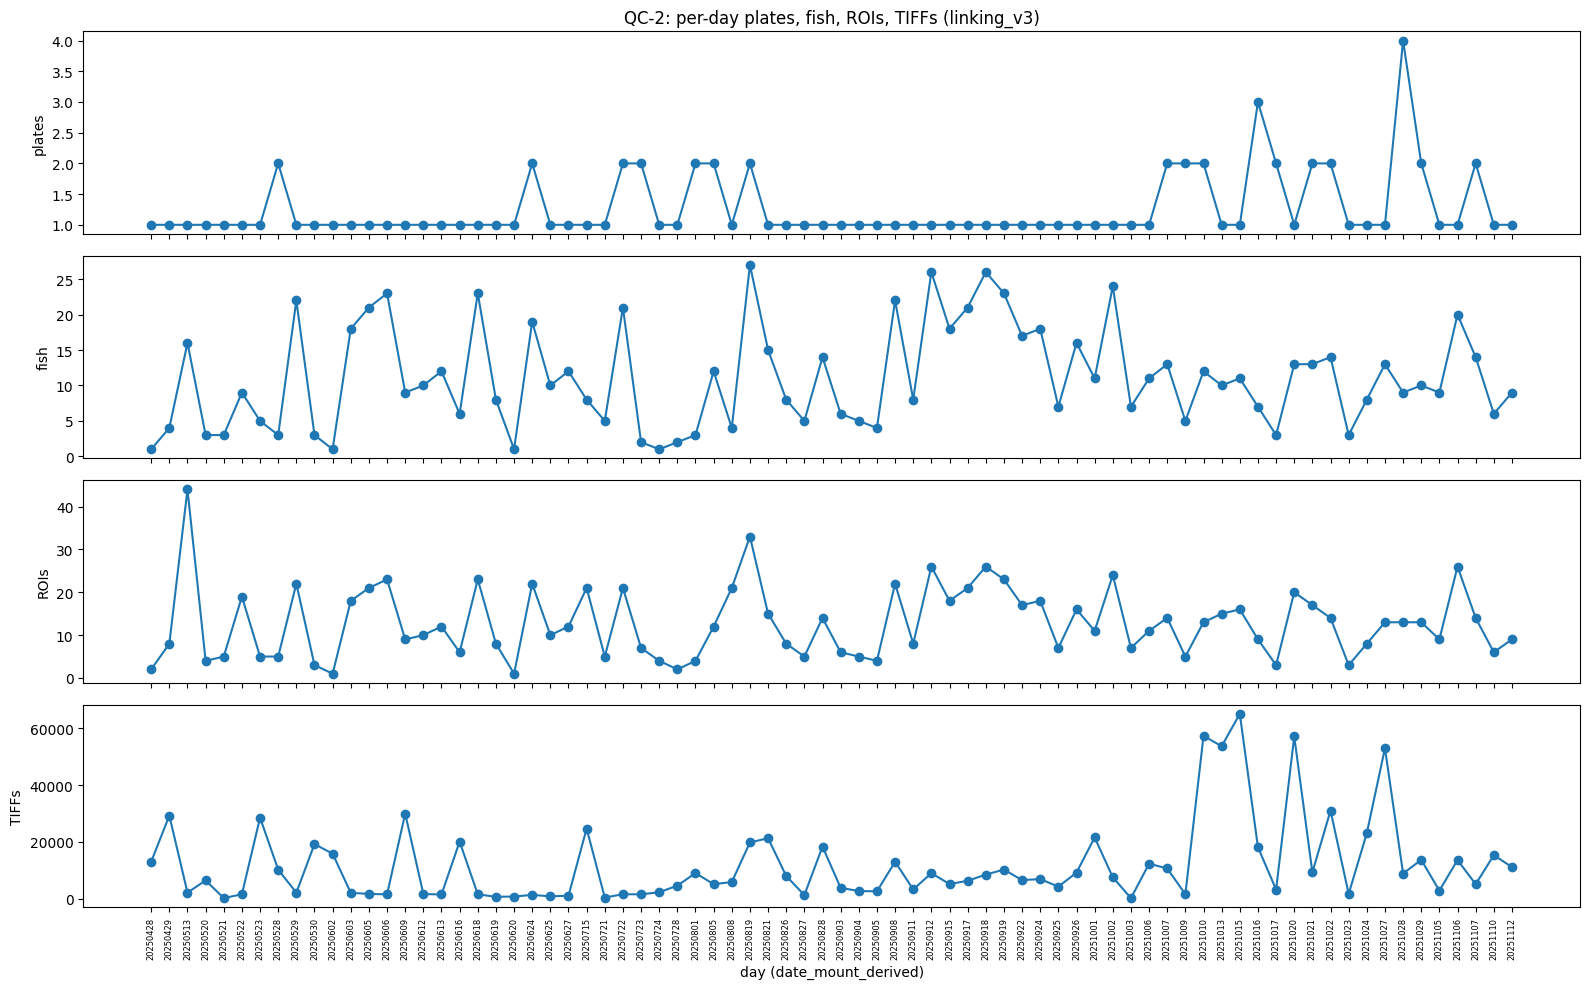

In [94]:
# QC-2 — per-day counts of plates, fish, ROIs, and TIFFs with stacked plots (readable x-axis)

import pandas as pd
import matplotlib.pyplot as plt

if "df_linked" not in globals():
    raise RuntimeError("df_linked is not defined. Run the linking cells before QC-2.")

# canonical day key from linking
day_key = df_linked["date_mount_derived"]

# ensure roi_tiffs is numeric
roi_tiffs_numeric = pd.to_numeric(df_linked.get("roi_tiffs", 0), errors="coerce").fillna(0)

qc_day = (
    df_linked.assign(day=day_key, roi_tiffs_num=roi_tiffs_numeric)
    .groupby("day")
    .agg(
        n_plates=("plate_id_filled", "nunique"),
        n_fish=("fish_folder", "nunique"),
        n_rois=("roi_dir", "count"),
        n_tiffs=("roi_tiffs_num", "sum"),
    )
    .reset_index()
    .sort_values("day")
)

print("QC-2: per-day counts (plates, fish, ROIs, TIFFs):")
print(qc_day)

# indices for x-axis
x = range(len(qc_day))
x_labels = qc_day["day"].tolist()

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

# 1) plates per day
axes[0].plot(x, qc_day["n_plates"], marker="o")
axes[0].set_ylabel("plates")
axes[0].set_title("QC-2: per-day plates, fish, ROIs, TIFFs (linking_v3)")

# 2) fish per day
axes[1].plot(x, qc_day["n_fish"], marker="o")
axes[1].set_ylabel("fish")

# 3) ROIs per day
axes[2].plot(x, qc_day["n_rois"], marker="o")
axes[2].set_ylabel("ROIs")

# 4) TIFFs per day
axes[3].plot(x, qc_day["n_tiffs"], marker="o")
axes[3].set_ylabel("TIFFs")
axes[3].set_xlabel("day (date_mount_derived)")

# set x ticks and labels on the bottom axis only
axes[3].set_xticks(x)
axes[3].set_xticklabels(x_labels, rotation=90, ha="center", fontsize=6)

plt.tight_layout()
plt.show()